In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pickle
import pandas as pd
from util import get_counts
from analysis import load_data

In [2]:
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
plt.rc('font', size=11)

if not os.path.exists("../output"):
    os.mkdir("../output")

if os.path.exists("../output/data.p"):
    annotated, references, corpus, dates = pickle.load(open("../output/data.p", "rb"))
else:
    annotated, references, corpus, dates = load_data("..")
    pickle.dump((annotated, references, corpus, dates), open("../output/data.p", "wb"))

<Figure size 600x450 with 0 Axes>

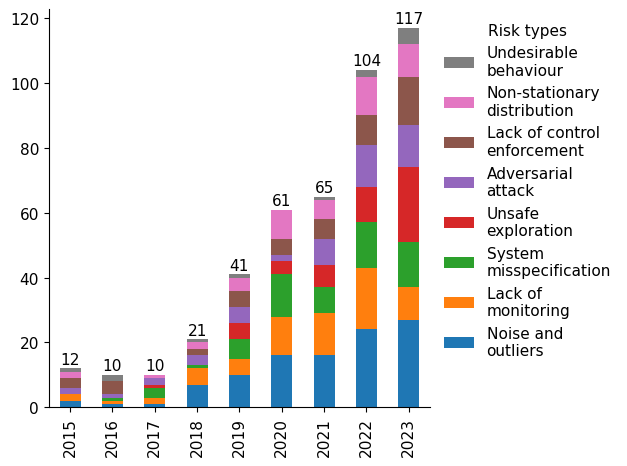

In [3]:
data = []
for key, ann in annotated.iterrows():
    for risk in ann["risks"]:
        data.append({
            "year": ann["year"],
            "risk": risk
        })
data = pd.DataFrame.from_records(data)
years = data.groupby("year")["risk"].value_counts().unstack().fillna(0).astype(int)
years = years[years.index >= 2015]
years = years[years.sum(0).sort_values(ascending=False).index]
complex = True
if complex:
    plt.figure(figsize=(6, 4.5))
    years.plot(kind="bar", stacked=True, color=mpl.colormaps.get_cmap("tab10").colors, linewidth=2)
    # Place total number of publications in that year on top of each bar
    for i, (year, row) in enumerate(years.iterrows()):
        plt.text(i, row.sum() + 0.5, row.sum(), ha="center", va="bottom")
    handles, labels = plt.gca().get_legend_handles_labels()
    order = [7, 6, 5, 4, 3, 2, 1, 0]
    plt.legend([handles[idx] for idx in order], [labels[idx] for idx in order], title="Risk types", bbox_to_anchor=(1, 1), frameon=False)
    # plt.title("Number of publications per year")
    plt.xlabel("")
    plt.tight_layout()
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.savefig("../output/pub-years.pdf")
    plt.show()
else:
    # Plot number of publications per year
    sns.set_style("whitegrid")
    plt.figure(figsize=(8, 6))
    year_counts = years.sum(1).reset_index().rename(columns={0: "count"})
    sns.catplot(year_counts, x="year", y="count", kind="bar", legend="auto", errorbar=None,
                ci=None, color=mpl.cm.get_cmap("tab10")(0), aspect=1.5)
    # Place counts above each bar
    for i, row in year_counts.iterrows():
        plt.text(i, row["count"] + 0.5, row["count"], ha="center", va="bottom")
    plt.ylabel("Number of publications")
    plt.xlabel("")
    # plt.gca().spines['top'].set_visible(False)
    # plt.gca().spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig("../output/pub-years-total.pdf")
    plt.show()

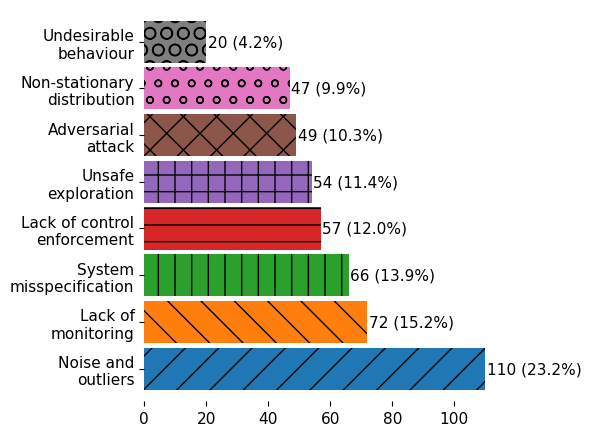

In [4]:
# Plot risk stats
counts = get_counts(annotated["risks"])
# draw_piechart(counts, "risks", inpct=0.6, pctcut=3)
# Draw a horizontal bar chart using the counts
plt.figure(figsize=(6, 4.5))
counts.plot.barh(color=mpl.colormaps.get_cmap("tab10").colors, width=0.9)

# Add different patterns to each bar
hatches = ['/', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*']
for i, bar in enumerate(plt.gca().patches):
    bar.set_hatch(hatches[i % len(hatches)])

# Add percentages to each bar
for i, v in enumerate(counts):
    plt.text(v + 0.5, i, f"{v} ({v / counts.sum() * 100:.1f}%)", va="center", ha="left")

# Remove all borders around plot
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.tight_layout()
plt.savefig("../output/risks.pdf")
plt.show()

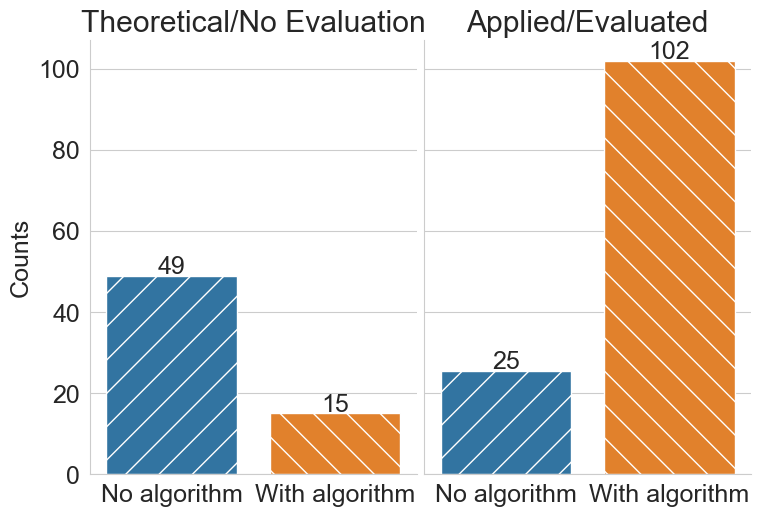

In [5]:
# Plot method type stats
params = plt.rcParams.copy()
sns.set_style("whitegrid")
plt.rc("font", size=18)
a = annotated.groupby(["framework", "algorithm"])["type"].value_counts()
a = a.reset_index()
g = sns.catplot(a, x="algorithm", y="count", col="type", kind="bar", legend="auto", errorbar=None,
                sharey=True, sharex=False, ci=None, palette="tab10", aspect=.75)
# Place counts over bars
for ax in g.axes.flat:
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width() / 2., p.get_height() + 0.5, int(p.get_height()), ha="center")
# Add hatches to bars
hatches = ['/', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*']
for i, ax in enumerate(g.axes.flat):
    for j, bar in enumerate(ax.patches):
        bar.set_hatch(hatches[j % len(hatches)])
g.set_xlabels("")
g.set_ylabels("Counts")
g.set_xticklabels(["No algorithm", "With algorithm"])
# g.legend.set_title("Proposes\nFramework?")
# g.legend.set_bbox_to_anchor((0.7, 0.5))
g.axes[0, 0].set_title("Theoretical/No Evaluation")
g.axes[0, 1].set_title("Applied/Evaluated")
plt.tight_layout(pad=0.05)
plt.savefig("../output/framework_algo.pdf")
plt.show()
plt.rcParams = params

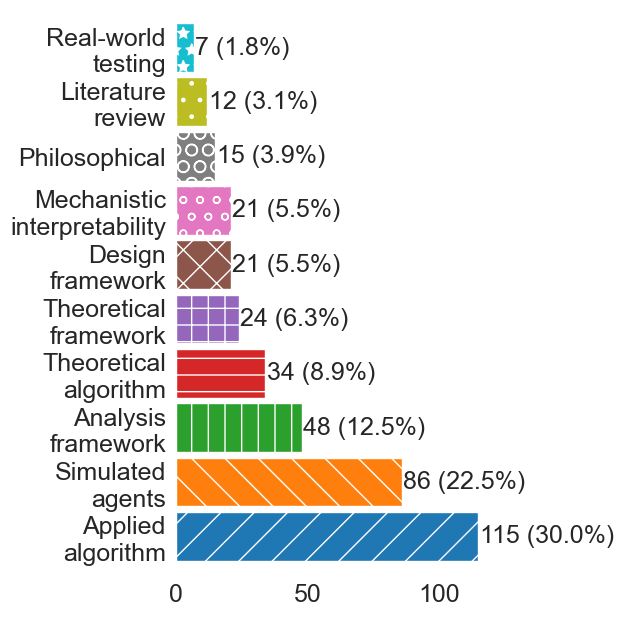

In [6]:
counts = get_counts(annotated["method"])
counts["analysis\nframework"] += counts["dataset"]
counts = counts.drop("dataset")
counts.index = counts.index.str.capitalize()
sns.set_style("whitegrid")
plt.figure(figsize=(6, 6))
counts.plot.barh(color=mpl.colormaps.get_cmap("tab10").colors, width=0.9)

# Add different patterns to each bar
hatches = ['/', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*']
for i, bar in enumerate(plt.gca().patches):
    bar.set_hatch(hatches[i % len(hatches)])

# Add percentages to each bar
for i, v in enumerate(counts):
    plt.text(v + 0.5, i, f"{v} ({v / counts.sum() * 100:.1f}%)", va="center", ha="left")

# Remove all borders around plot
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.tight_layout(pad=0.05)
plt.savefig("../output/methods.pdf", bbox_inches="tight")
plt.show()

In [51]:
annotated.groupby(["framework", "algorithm"])["type"].value_counts()

framework  algorithm  type       
False      False      theoretical     43
                      applied         27
           True       applied        196
                      theoretical     27
True       False      theoretical     55
                      applied         24
           True       applied          8
                      theoretical      3
Name: count, dtype: int64

383